In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [10]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,109,36
1,2,Male,32,32,95
2,3,Male,61,109,70
3,4,Male,55,69,5
4,5,Male,23,42,30


In [11]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [12]:
df["Gender"] = df["Gender"].map({"Male":0,"Female":1})

In [13]:
X = df.drop("CustomerID", axis=1)

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

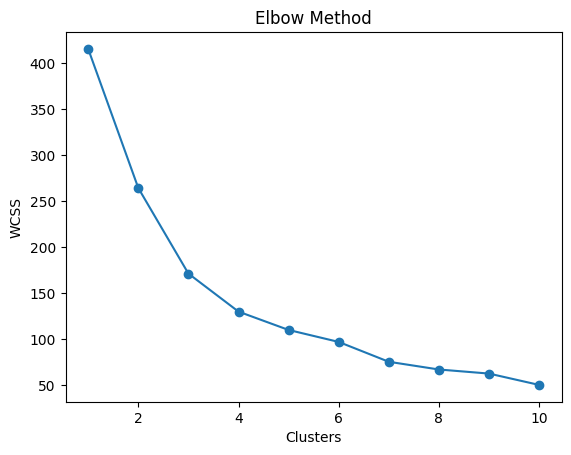

In [16]:
wcss=[]

for i in range(1,11):
    model=KMeans(n_clusters=i,random_state=42)
    model.fit(X_pca)
    wcss.append(model.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [17]:
for i in range(2,11):
    model=KMeans(n_clusters=i,random_state=42)
    labels=model.fit_predict(X_pca)
    print("Clusters:",i," Score:",silhouette_score(X_pca,labels))

Clusters: 2  Score: 0.3377318976063657
Clusters: 3  Score: 0.3612104835934158
Clusters: 4  Score: 0.34473664452760433
Clusters: 5  Score: 0.34704043169073373
Clusters: 6  Score: 0.33198686540523986
Clusters: 7  Score: 0.3487615174242565
Clusters: 8  Score: 0.34397059319851797
Clusters: 9  Score: 0.32691934524625466
Clusters: 10  Score: 0.36854266285566667


In [18]:
kmeans=KMeans(n_clusters=5,random_state=42)
clusters=kmeans.fit_predict(X_pca)

df["Cluster"]=clusters

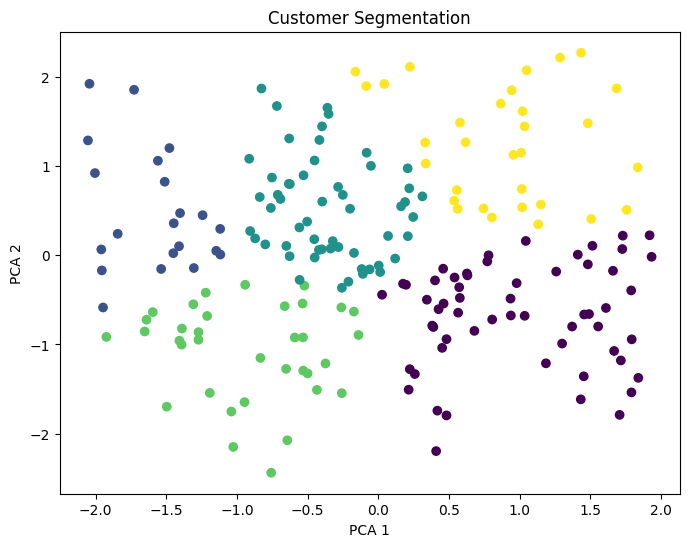

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],X_pca[:,1],c=clusters,cmap="viridis")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segmentation")

plt.show()

In [20]:
df.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,100.172414,0.224138,38.379310,54.844828,75.293103
1,100.333333,1.000000,44.523810,105.000000,19.476190
2,100.036364,0.545455,47.018182,96.690909,43.290909
3,97.285714,0.914286,34.285714,50.542857,35.000000
4,105.677419,0.000000,53.838710,111.774194,64.645161
